     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
(5572, 5)
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64
  category                                            message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U

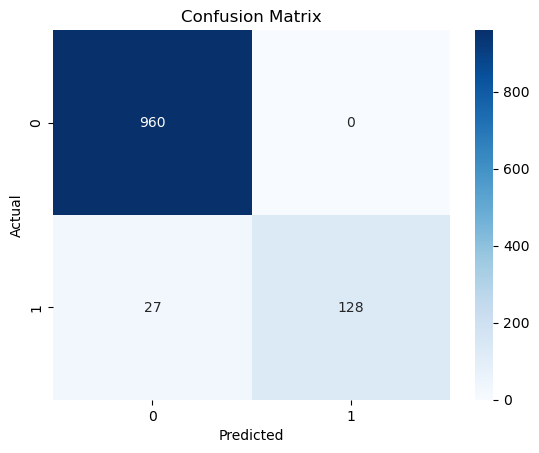

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer

import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

df = pd.read_csv("spam dataset.csv", encoding="latin-1")

# Display first 5 rows

print(df.head())

# Shape

print(df.shape)

# Null values

print(df.isnull().sum())

# Remove unwanted columns

cols = df.columns.difference(['v1', 'v2'])
df = df.drop(columns=cols)

# Rename columns

df = df.rename(columns={
'v1': 'category',
'v2': 'message'
})

print(df.head())

# Convert labels

df['category'] = df['category'].apply(
lambda x: 1 if x == 'spam' else 0
)

print(df.head())

# Independent and Dependent Variables

x = df['message']
y = df['category']

# Train Test Split

x_train, x_test, y_train, y_test = train_test_split(
x,
y,
test_size=0.2,
random_state=3
)

# TF-IDF Vectorization

vectorizer = TfidfVectorizer()

x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)

# Logistic Regression Model

model = LogisticRegression()

model.fit(x_train, y_train)

# Prediction

y_pred = model.predict(x_test)

# Accuracy

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Precision

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
